# Task 2: Clustering the Kick dataset

In [21]:
#Load & initial preprocessing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

random_state = 42

In [22]:
# not skipping empty values, to demonstrate data preprocessing steps later
df = pd.read_csv("Datasets/kick.csv", na_filter=False)
df.info()

# Summary statsics
print(df['VehOdo'].describe())
print(df['MMRAcquisitionAuctionAveragePrice'].describe())
print(df['WarrantyCost'].describe())
print(df['IsBadBuy'].value_counts())
print(df['Make'].value_counts())
print(df['Make'].unique())
print(df['IsBadBuy'].unique())

# Convert to numeric and handle blanks
df['VehOdo'] = df['VehOdo'].replace('', np.nan).astype(float)
df['MMRAcquisitionAuctionAveragePrice'] = df['MMRAcquisitionAuctionAveragePrice'].replace('', np.nan).astype(float)
df['WarrantyCost'] = df['WarrantyCost'].replace('', np.nan).astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41409 entries, 0 to 41408
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   VehOdo                             41409 non-null  int64 
 1   MMRAcquisitionAuctionAveragePrice  41409 non-null  int64 
 2   Make                               41409 non-null  object
 3   WarrantyCost                       41409 non-null  int64 
 4   IsBadBuy                           41409 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.6+ MB
count     41409.000000
mean      71299.961868
std       14723.019112
min         577.000000
25%       61586.000000
50%       73128.000000
75%       82256.000000
max      480444.000000
Name: VehOdo, dtype: float64
count    41409.000000
mean      6135.010433
std       2481.223003
min          0.000000
25%       4273.000000
50%       6105.000000
75%       7783.000000
max      33543.000000
Name: MMRAcq

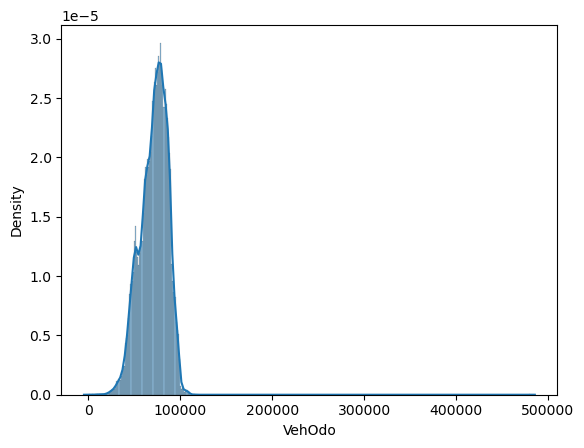

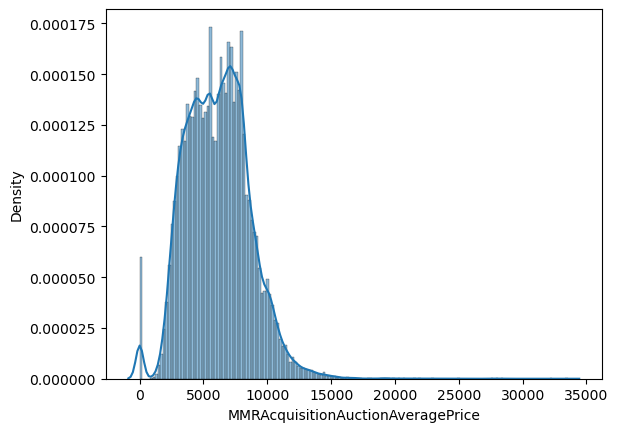

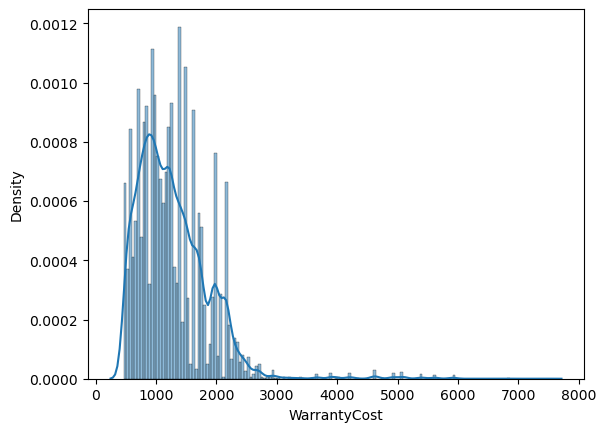

In [23]:
# Visualise distributions (before cleaning)

sns.histplot(df['VehOdo'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['MMRAcquisitionAuctionAveragePrice'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['WarrantyCost'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

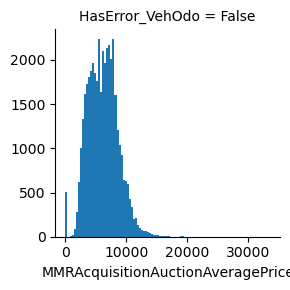

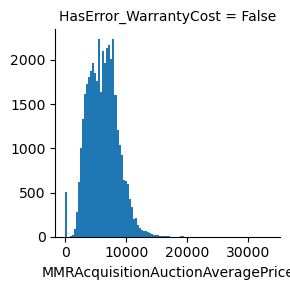

Row # before dropping erroneous rows 41409
Row # after dropping erroneous rows 40907


In [24]:
# Error flags and cleaning
df['HasError_VehOdo'] = df['VehOdo'] < 0
sns.FacetGrid(df, col='HasError_VehOdo').map(plt.hist, 'MMRAcquisitionAuctionAveragePrice', bins=100)
plt.show()

df['HasError_WarrantyCost'] = df['WarrantyCost'] <= 0
sns.FacetGrid(df, col='HasError_WarrantyCost').map(plt.hist, 'MMRAcquisitionAuctionAveragePrice', bins=100)
plt.show()

print("Row # before dropping erroneous rows", len(df))
df = df[df['VehOdo'] >= 0]
df = df[df['MMRAcquisitionAuctionAveragePrice'] > 0]
df = df[df['WarrantyCost'] >= 0]
df = df[df['Make'].notna()]
print("Row # after dropping erroneous rows", len(df))

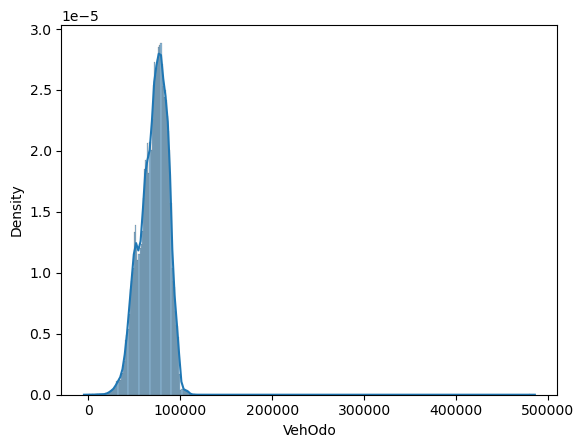

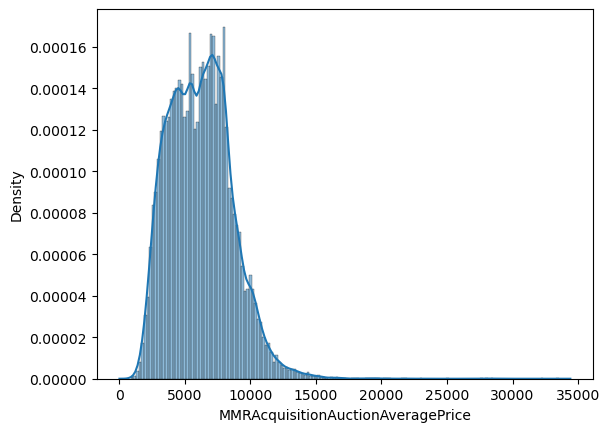

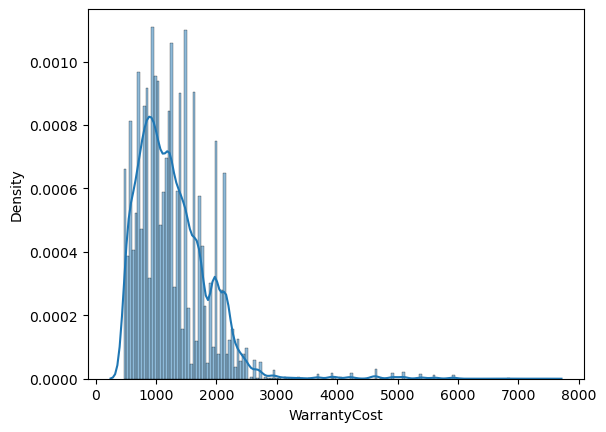

In [25]:
# Visualise distributions (after cleaning)
sns.histplot(df['VehOdo'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['MMRAcquisitionAuctionAveragePrice'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

sns.histplot(df['WarrantyCost'].dropna(), kde=True, stat="density", kde_kws=dict(cut=3))
plt.show()

Clustering Model: K-Means

In [26]:
# Selected features
df2 = df[['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost']].copy()
X = df2.to_numpy()
print(df2.columns)

Index(['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost'], dtype='object')


In [27]:
# Standardize numerical features (optional but better results)
scaler = StandardScaler()
X = scaler.fit_transform(X)

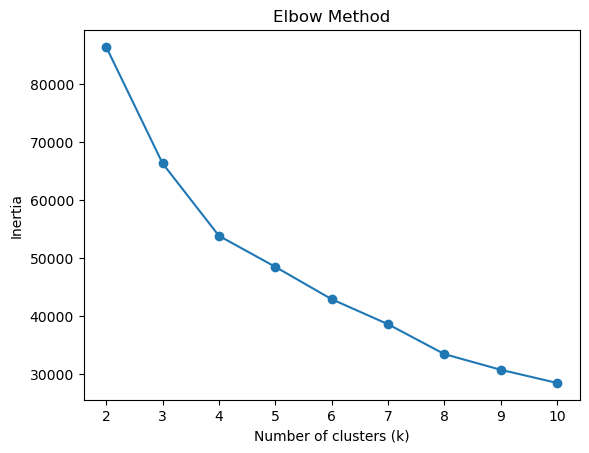

In [28]:
# Elbow method
inertia_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia_scores.append(model.inertia_)

plt.plot(range(2, 11), inertia_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig("Outputs/kmean_elbow.png", dpi=180)
plt.show()

In [29]:
# As the elbow method is a little inconlusive, we also implemented the silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# silhouette score
k_values = [3, 4]
models = [KMeans(n_clusters=k, random_state=42).fit(X) for k in k_values]

for model, k in zip(models, k_values):
    labels = model.predict(X)
    score = silhouette_score(X, labels)
    print(f"KMeans(n_clusters={k})")
    print(f"Silhouette score for k={k}: {score:.4f}\n")

KMeans(n_clusters=3)
Silhouette score for k=3: 0.2923

KMeans(n_clusters=4)
Silhouette score for k=4: 0.2864



In [30]:
# Fit KMeans clustering with three clusters
model = KMeans(n_clusters=3, random_state=random_state)
model.fit(X)

df2['Cluster_ID'] = model.predict(X)

print("Cluster centroids:")
for centroid in model.cluster_centers_:
    print(centroid)

Cluster centroids:
[0.47085978 1.01022309 0.27255469]
[-0.98913415 -0.10517814 -0.67210356]
[ 0.66682583 -0.82085023  0.49711181]


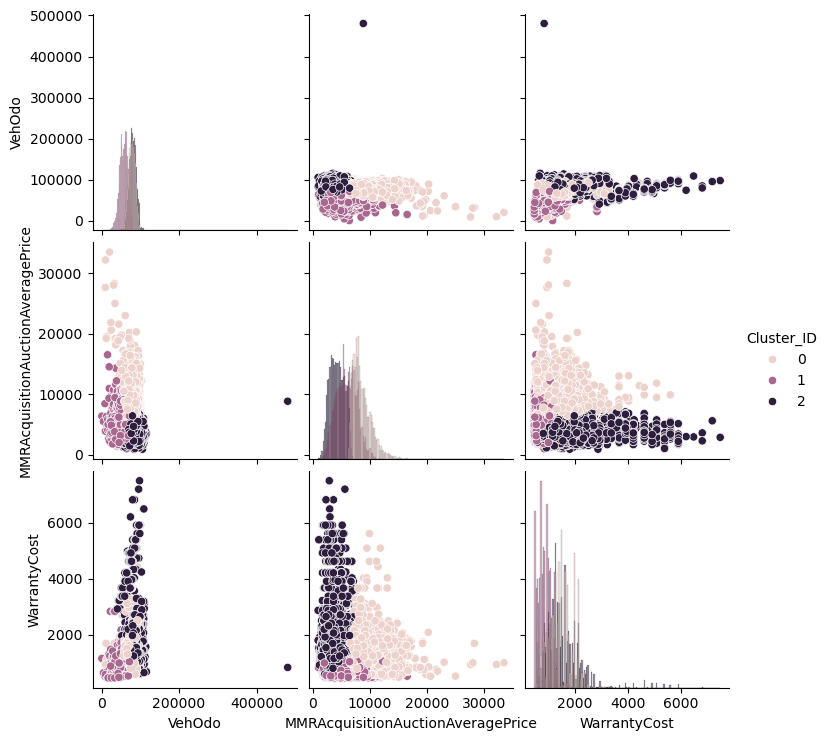

In [31]:
# Pairplot
sns.pairplot(df2, hue='Cluster_ID', diag_kind='hist')
plt.savefig("Outputs/kmeans_pairplot.png", dpi=180)
plt.show()

Distribution for cluster 0


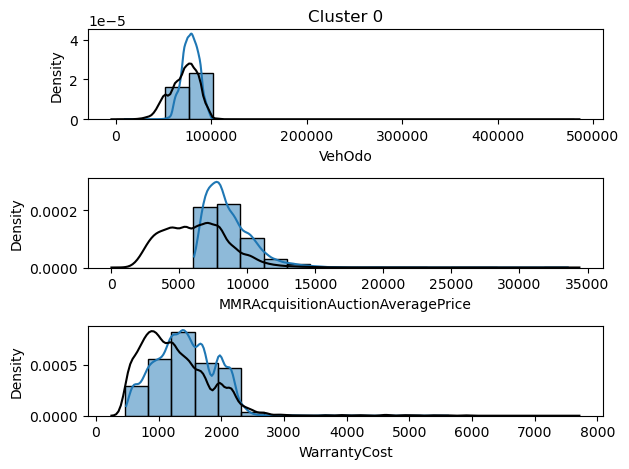

Distribution for cluster 1


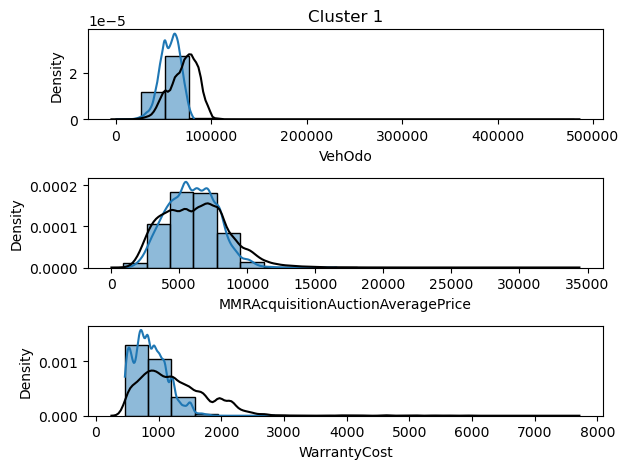

Distribution for cluster 2


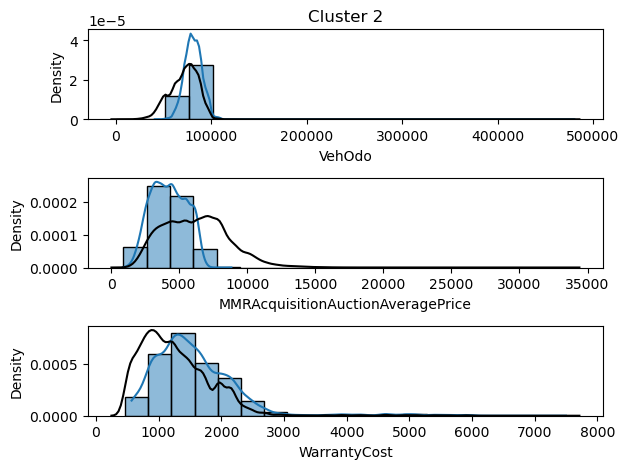

In [32]:
# Inspect clusters
def inspect_clusters(df, cols, clusters_to_inspect):
    n_bins = 20
    for cluster in clusters_to_inspect:
        print("Distribution for cluster {}".format(cluster))
        fig, ax = plt.subplots(nrows=len(cols))
        ax[0].set_title("Cluster {}".format(cluster))
        for j, col in enumerate(cols):
            bins = np.linspace(min(df[col]), max(df[col]), 20)
            sns.histplot(df[df['Cluster_ID'] == cluster][col], bins=bins,
                         ax=ax[j], kde=True, stat="density")
            sns.kdeplot(data=df[col], ax=ax[j], color="k")
        plt.tight_layout()
        plt.show()

inspect_clusters(df2, 
                 cols=['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost'], 
                 clusters_to_inspect=[0, 1, 2])

New clustering model with the Make variable 

KPrototypes with Standardizing and K=3

In [33]:
selected_features = ['VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'WarrantyCost', 'Make']
df2 = df[selected_features].copy()

df2['Make'] = df2['Make'].astype(str)

X = df2.to_numpy()

In [36]:
from kmodes.kprototypes import KPrototypes

kproto = KPrototypes(n_clusters=3, random_state=42)
clusters = kproto.fit_predict(X, categorical=[3]) 

df2['Cluster_ID'] = clusters

print("Cluster centroids:")
for idx, centroid in enumerate(kproto.cluster_centroids_):
    print(f"Cluster {idx}: {centroid}")

Cluster centroids:
Cluster 0: ['85448.83066055746' '6180.689003436426' '1514.2469135802469' 'CHEVROLET']
Cluster 1: ['69285.51784737002' '6212.752204317421' '1249.7900273639405' 'CHEVROLET']
Cluster 2: ['49656.78909465021' '6258.869455875629' '883.1978737997257' 'DODGE']


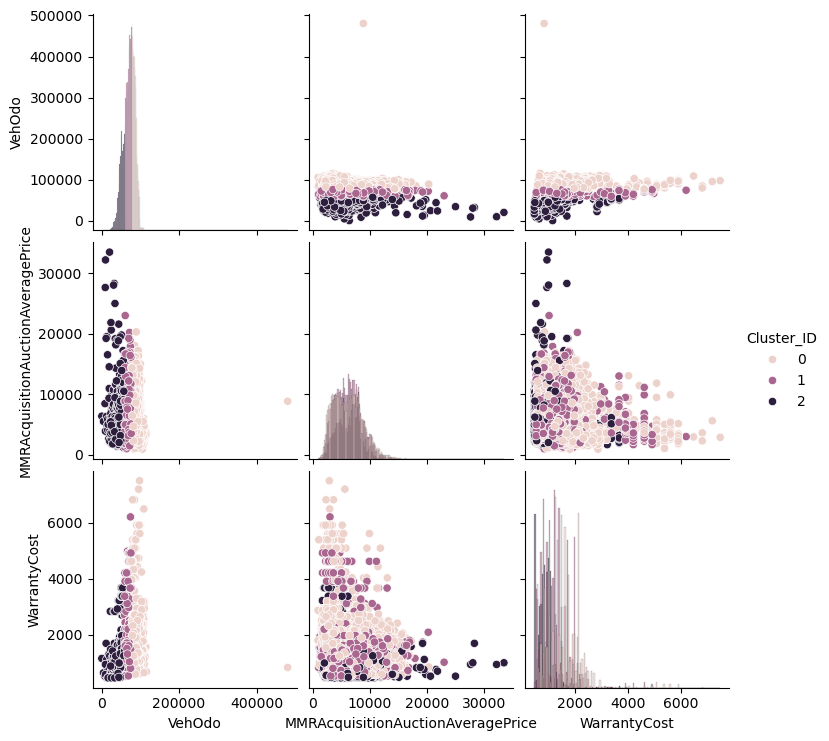

In [35]:
# Pairplot
sns.pairplot(df2, hue='Cluster_ID', diag_kind='hist')
plt.savefig("Outputs/kprototypes_pairplot.png", dpi=180)
plt.show()